# 03 — SHAP Explanations

For each window pair (A, B), the notebook computes per-replica SHAP attributions on
the flagged set F_{A,B}. The explainer used depends on `MODEL_TYPE`:

| MODEL_TYPE  | Explainer               | Properties                                                |
|-------------|-------------------------|-----------------------------------------------------------|
| `xgboost`   | `shap.TreeExplainer`    | deterministic for a fixed fitted tree model; runs on CPU  |
| `mlp_plr`   | `shap.GradientExplainer`| stochastic, approximate; requires GPU                     |

**Output layout** (under `data/shap/{MODEL_TYPE}/pair_{pid:02d}/`):
- `shap_A.npy`, `shap_B.npy` — shape `(R, n_explained, p)`, float32.
  For XGBoost, `n_explained = |F|`; for MLP-PLR, `n_explained` may be a capped SHAP subsample.
- `mlp_shap_subsample_idx.npy` *(MLP-PLR only)* — positions within `flagged_idx` used for MLP-SHAP.
- `run_params.json` — explainer configuration fingerprint for stale-output detection.
- `expected_values_A.npy`, `expected_values_B.npy` — shape `(R,)`, float32
- `stochasticity.json` — `{best_replica_A, max_abs_diff, median_abs_diff*, is_deterministic}`
  *(\*`median_abs_diff` only present for MLP-PLR)*
- `global_importance_pair00_A.png` — top-20 global importance plot for pair 0

**Coordinate system note (MLP-PLR):** MLP-PLR models are trained on *scaled* features
(each replica has its own `StandardScaler`). SHAP attributions are computed in the
scaled-feature space and saved as such. Feature positions still match the 119-column
ordering in `feature_names.json` — only magnitudes differ. 

Cosine distance and RBO-on-|attribution| rankings reduce the emphasis on raw
magnitude differences, but they do not make the comparison independent of
per-replica scaling or background choices. The MLP-PLR SHAP results should
therefore be interpreted as end-to-end explanation behaviour for the fitted
replica pipelines.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import joblib
import numpy as np
import pandas as pd
import shap
from pathlib import Path
import hashlib

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Model type — must match the MODEL_TYPE used in notebook 02 / 02b ──
MODEL_TYPE = 'xgboost'   # 'xgboost' | 'mlp_plr'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
SHAP_DIR  = WORKSPACE / 'data' / 'shap'  / MODEL_TYPE
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print(f'SHAP version: {shap.__version__}')
print(f'MODEL_TYPE : {MODEL_TYPE}')


SHAP version: 0.51.0
MODEL_TYPE : xgboost


In [3]:
# Load data and window config
X      = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)
with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)
feature_names = feature_names_json['all']   # flat list of 119 feature names in column order

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

print(f'X: {X.shape}, features: {len(feature_names)}')
print(f'R={R}, {len(pairs)} pairs')

X: (160057, 119), features: 119
R=2, 2 pairs


In [4]:
# ═════════════════════════════════════════════════════════════════════════════
# MLP-PLR setup — only runs when MODEL_TYPE == 'mlp_plr'.
# The MLPPLR / PLREmbedding classes below must be byte-identical with the copies
# in 02b_training_replicas_mlp_plr.ipynb. If 02b's architecture changes, mirror
# the change here.
# ═════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == 'mlp_plr':
    import math
    import torch
    import torch.nn as nn

    assert torch.cuda.is_available(), 'MLP-PLR SHAP requires a GPU runtime.'
    DEVICE = torch.device('cuda')
    print(f'PyTorch : {torch.__version__}')
    print(f'Device  : {torch.cuda.get_device_name(0)}')

    # Derive numeric / binary column indices (not assumed contiguous)
    num_col_idx = [feature_names.index(fn) for fn in feature_names_json['num']]
    bin_col_idx = [i for i in range(len(feature_names))
                   if i not in set(num_col_idx)]
    n_num = len(num_col_idx)
    n_bin = len(bin_col_idx)
    print(f'Numeric cols: {n_num}  Binary cols: {n_bin}')


    class PLREmbedding(nn.Module):
        """Vectorised PLR embedding for all numeric features at once.

        Per feature (no weight sharing across features):
            periodic(x)  :  v = 2π · c · x        c ∈ ℝ^k, c ~ N(0, sigma_init^2)
                            [sin(v), cos(v)]      → ℝ^(2k)
            linear       :  W·[sin,cos] + b       W ∈ ℝ^(2k × d), b ∈ ℝ^d
            relu         :  max(0, ·)             → ℝ^d

        Implemented as batched tensors of shape (n_num_features, …) with an einsum
        in forward, which is ~100× faster than a Python loop per feature.
        """

        def __init__(self, n_num_features: int, k_periodic: int,
                     sigma_init: float, d_embedding: int):
            super().__init__()
            self.n_num_features = n_num_features
            self.k_periodic     = k_periodic
            self.d_embedding    = d_embedding

            # Per-feature coefficient vectors c, initialised ~ N(0, sigma_init^2)
            self.c = nn.Parameter(torch.randn(n_num_features, k_periodic) * sigma_init)

            # Per-feature linear weights & biases (no weight sharing)
            self.W = nn.Parameter(torch.empty(n_num_features, 2 * k_periodic, d_embedding))
            self.b = nn.Parameter(torch.zeros(n_num_features, d_embedding))
            nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

        def forward(self, x_num: torch.Tensor) -> torch.Tensor:
            # x_num: (batch, n_num_features)
            # v: (batch, n_num_features, k_periodic)
            v = (2.0 * math.pi) * self.c.unsqueeze(0) * x_num.unsqueeze(-1)
            # pe: (batch, n_num_features, 2k)
            pe = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)
            # Per-feature Linear: 'bnk,nkd->bnd'
            out = torch.einsum('bnk,nkd->bnd', pe, self.W) + self.b.unsqueeze(0)
            out = torch.relu(out)
            # Flatten features: (batch, n_num_features * d_embedding)
            return out.reshape(out.shape[0], -1)


    class MLPPLR(nn.Module):
        """MLP-PLR: PLR embeddings for numeric features + MLP backbone on the
        concatenation of embedded numeric + raw binary features.

        Outputs a single logit per instance (no sigmoid — use BCEWithLogitsLoss).
        Column routing (num_col_idx / bin_col_idx) is stored as non-trainable
        buffers so it travels with state_dict and reconstructs correctly.
        """

        def __init__(self, n_num_features: int, n_bin_features: int,
                     k_periodic: int, sigma_init: float, d_embedding: int,
                     n_layers: int, hidden_dim: int, dropout: float,
                     num_col_idx, bin_col_idx):
            super().__init__()
            self.n_num_features = n_num_features
            self.n_bin_features = n_bin_features

            # Column routing as buffers (survive state_dict save/load)
            self.register_buffer('num_col_idx_buf',
                                 torch.as_tensor(num_col_idx, dtype=torch.long))
            self.register_buffer('bin_col_idx_buf',
                                 torch.as_tensor(bin_col_idx, dtype=torch.long))

            self.plr = PLREmbedding(n_num_features, k_periodic, sigma_init, d_embedding)

            # MLP backbone
            input_dim = n_num_features * d_embedding + n_bin_features
            layers = []
            in_dim = input_dim
            for _ in range(n_layers):
                layers.extend([
                    nn.Linear(in_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ])
                in_dim = hidden_dim
            self.backbone = nn.Sequential(*layers)
            self.head     = nn.Linear(hidden_dim, 1)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            # x: (batch, n_total_features) — the full 119-column input
            x_num = x.index_select(1, self.num_col_idx_buf)   # (batch, n_num)
            x_bin = x.index_select(1, self.bin_col_idx_buf)   # (batch, n_bin)
            emb   = self.plr(x_num)                            # (batch, n_num * d_emb)
            z     = torch.cat([emb, x_bin], dim=-1)            # (batch, input_dim)
            h     = self.backbone(z)                           # (batch, hidden_dim)
            logit = self.head(h).squeeze(-1)                   # (batch,)
            return logit



    class ShapOutputAdapter(nn.Module):
        """Wrap an MLPPLR so its output is 2-D (batch, 1) instead of 1-D (batch,).

        `shap.GradientExplainer` indexes outputs with `outputs[:, idx]` internally,
        which raises `IndexError: too many indices for tensor of dimension 1` on a
        bare MLPPLR (whose forward ends with .squeeze(-1) for BCEWithLogitsLoss).
        This adapter preserves gradients and adds back the trailing dimension.
        """

        def __init__(self, inner: nn.Module):
            super().__init__()
            self.inner = inner

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.inner(x).unsqueeze(-1)


    def load_mlp_plr_replica(bundle_path, device):
        """Load a joblib bundle from 02b and return (model on device in eval mode, scaler)."""
        bundle = joblib.load(bundle_path)
        model  = MLPPLR(**bundle['arch_config'])
        model.load_state_dict(bundle['state_dict'])
        model.to(device).eval()
        return model, bundle['scaler']


    def scale_numeric_inplace(X_in: np.ndarray, scaler, num_idx) -> np.ndarray:
        """Return a copy of X_in with numeric columns scaled (binary cols pass through)."""
        out = X_in.copy()
        out[:, num_idx] = scaler.transform(X_in[:, num_idx])
        return out


    print('MLP-PLR setup complete (classes + helpers defined).')


## SHAP computation loop

For each pair and each replica:
1. Load the model (XGBoost was trained on unscaled data — no scaler needed here).
2. Compute TreeSHAP values via `shap.TreeExplainer` on the raw (unscaled) flagged instances.
3. Capture `explainer.expected_value` (log-odds base value) per replica.

Results are saved immediately after each pair to allow resuming.

In [5]:
# ═════════════════════════════════════════════════════════════════════════════
# Run-configuration fingerprinting for stale-output detection
# ═════════════════════════════════════════════════════════════════════════════

SEED_BASE = 42

# MLP-PLR SHAP runtime settings.
# Kept as top-level constants so they are included in run_params.json.
MLP_BG_SIZE         = 100
MLP_SHAP_BATCH_SIZE = 512

# MLP-PLR SHAP subsampling. XGBoost still explains the full flagged set.
# When MLP_SHAP_SUBSAMPLE is True and N_MLP_SHAP_SUBSAMPLE matches LIME's
# N_LIME_SUBSAMPLE, the MLP-SHAP and LIME subsamples are byte-identical for
# each pair (same construction, same seed) — independently of run order.
MLP_SHAP_SUBSAMPLE   = True
N_MLP_SHAP_SUBSAMPLE = 200


def build_subsample_idx(flagged_local_idx: np.ndarray,
                        p_hat_A: np.ndarray, p_hat_B: np.ndarray,
                        n_subsample: int, seed: int) -> np.ndarray:
    """Stratified-by-risk subsample of flagged_local_idx.

    Sort flagged instances by max(p_hat_A, p_hat_B) (which is how they were
    flagged), then pick approximately evenly spaced rank positions. This
    covers the full risk range within the flagged set rather than clustering.
    Returns positions *within flagged_local_idx*.

    NOTE: This must remain byte-identical with the copy in 03b_lime_explanations.
    Do not edit one without the other.
    """
    rng = np.random.default_rng(seed)
    n_flagged = len(flagged_local_idx)
    if n_subsample >= n_flagged:
        return np.arange(n_flagged, dtype=np.int64)
    score = np.maximum(p_hat_A[flagged_local_idx], p_hat_B[flagged_local_idx])
    rank_order = np.argsort(-score)   # descending
    step = n_flagged / n_subsample
    picks = np.array([int(i * step + rng.uniform(0, step))
                      for i in range(n_subsample)], dtype=np.int64)
    picks = np.clip(picks, 0, n_flagged - 1)
    picks = np.unique(picks)
    if len(picks) < n_subsample:
        remaining = np.setdiff1d(np.arange(n_flagged), picks)
        extra = rng.choice(remaining, size=n_subsample - len(picks), replace=False)
        picks = np.concatenate([picks, extra])
    return np.sort(rank_order[picks[:n_subsample]]).astype(np.int64)


def array_sha1(arr: np.ndarray) -> str:
    """Stable hash for numpy arrays used in run-configuration fingerprints."""
    arr_c = np.ascontiguousarray(arr)
    return hashlib.sha1(arr_c.view(np.uint8)).hexdigest()


def load_json_if_exists(path: Path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def outputs_are_current(required_files: list, run_params_file: Path,
                        current_params: dict) -> bool:
    """Return True only if all outputs exist and run_params exactly match."""
    if not all(p.exists() for p in required_files):
        return False
    saved_params = load_json_if_exists(run_params_file)
    return saved_params == current_params


def load_training_run_params(pair_dir: Path):
    """Include training run_params in the explainer fingerprint if available."""
    return load_json_if_exists(pair_dir / 'run_params.json')


def make_shap_run_params(pair_id: int,
                         pair_dir: Path,
                         flagged_local_idx: np.ndarray,
                         n_explained: int,
                         n_features: int,
                         subset_within_flagged: np.ndarray | None = None) -> dict:
    """Full SHAP configuration fingerprint for one pair."""
    if subset_within_flagged is None:
        subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

    if MODEL_TYPE == 'xgboost':
        shap_config = {
            'variant':       'TreeExplainer',
            'model_output':  'raw',
            'output_scale':  'raw_margin_log_odds',
            'background':    None,
        }
    elif MODEL_TYPE == 'mlp_plr':
        shap_config = {
            'variant':              'GradientExplainer',
            'output_scale':         'pre_sigmoid_logit',
            'background':           'sampled_from_corresponding_training_window',
            'background_size':      int(MLP_BG_SIZE),
            'batch_size':           int(MLP_SHAP_BATCH_SIZE),
            'mlp_shap_subsample':   bool(MLP_SHAP_SUBSAMPLE),
            'n_mlp_shap_subsample': int(N_MLP_SHAP_SUBSAMPLE),
        }
    else:
        shap_config = {'variant': None}

    return {
        'explainer':                  'shap',
        'model_type':                 MODEL_TYPE,
        'pair_id':                    int(pair_id),
        'R':                          int(R),
        'n_features':                 int(n_features),
        'n_flagged_total':            int(len(flagged_local_idx)),
        'n_explained':                int(n_explained),
        'flagged_idx_sha1':           array_sha1(flagged_local_idx.astype(np.int64)),
        'subset_within_flagged_sha1': array_sha1(subset_within_flagged.astype(np.int64)),
        'shap_version':               str(shap.__version__),
        'training_run_params':        load_training_run_params(pair_dir),
        'shap_config':                shap_config,
    }


# ═════════════════════════════════════════════════════════════════════════════
# Main SHAP loop
# ═════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'

        print(f'\n── Pair {pid:02d} ──────────────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx = pred_data['flagged_idx']
        idx_eval = np.array(p['idx_eval'], dtype=np.int64)

        flagged_global_idx = idx_eval[flagged_local_idx]
        X_flagged = X[flagged_global_idx]   # raw, unscaled

        n_flagged = X_flagged.shape[0]
        n_feat    = X_flagged.shape[1]
        print(f'  Flagged instances: {n_flagged:,}  Features: {n_feat}')

        if n_flagged == 0:
            print('  WARNING: no flagged instances — skipping.')
            continue

        # ── Skip-if-current ─────────────────────────────────────────────────
        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path,
            shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_flagged,
            n_features            = n_feat,
            subset_within_flagged = np.arange(n_flagged, dtype=np.int64),
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved_params = load_json_if_exists(run_params_file)
        if saved_params is not None:
            changed_keys = [k for k in current_run_params
                            if saved_params.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # ── SHAP for replicas of window A ──────────────────────────────────
        shap_A = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_A' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_flagged)
            if isinstance(vals, list): vals = vals[1]
            shap_A[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_A[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  A replica {r}: SHAP computed  |mean|={np.abs(shap_A[r]).mean():.5f}  base={ev_A[r]:.4f}')

        # ── SHAP for replicas of window B ──────────────────────────────────
        shap_B = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_B' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_flagged)
            if isinstance(vals, list): vals = vals[1]
            shap_B[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_B[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  B replica {r}: SHAP computed  |mean|={np.abs(shap_B[r]).mean():.5f}  base={ev_B[r]:.4f}')

        # ── Sanity check: SHAP values should sum to log-odds prediction − base_value ──
        model_A0  = joblib.load(pair_dir / 'replicas_A' / 'model_r0.joblib')
        preds_raw = model_A0.predict(X_flagged, output_margin=True)
        shap_sum  = shap_A[0].sum(axis=1) + ev_A[0]
        max_err   = np.abs(shap_sum - preds_raw).max()
        print(f'  Sanity (A r0): max |SHAP_sum - log_odds| = {max_err:.6f}')
        if max_err > 0.01:
            print('  WARNING: SHAP consistency error too large!')
        else:
            print('  Sanity check passed.')

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE    = MLP_BG_SIZE
    BATCH_SIZE = MLP_SHAP_BATCH_SIZE

    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'

        print(f'\n── Pair {pid:02d} [mlp_plr] ──────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx  = pred_data['flagged_idx']
        p_hat_A            = pred_data['p_hat_A']
        p_hat_B            = pred_data['p_hat_B']
        idx_A              = np.array(p['idx_A'],    dtype=np.int64)
        idx_B              = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval           = np.array(p['idx_eval'], dtype=np.int64)
        flagged_global_idx = idx_eval[flagged_local_idx]

        # Optionally restrict SHAP computation to a subsample. The construction
        # and seed are identical to LIME's (seed = SEED_BASE + pid*100), so when
        # N_MLP_SHAP_SUBSAMPLE == N_LIME_SUBSAMPLE the explained instances are
        # byte-identical between the two explainers — without depending on the
        # LIME notebook having run already.
        if MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, p_hat_A, p_hat_B,
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        X_flagged_full = X[flagged_global_idx]                       # (|F|, p) raw
        X_flagged      = X_flagged_full[subset_within_flagged]       # (n_explained, p) raw

        n_flagged_total = X_flagged_full.shape[0]
        n_explained     = X_flagged.shape[0]
        n_feat          = X_flagged.shape[1]
        print(f'  Flagged total: {n_flagged_total:,}  Explained: {n_explained}  Features: {n_feat}')

        if n_explained == 0:
            print('  WARNING: no instances to explain — skipping.')
            continue

        # ── Skip-if-current ─────────────────────────────────────────────────
        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path,
            shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            subset_path,
            run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_explained,
            n_features            = n_feat,
            subset_within_flagged = subset_within_flagged,
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved_params = load_json_if_exists(run_params_file)
        if saved_params is not None:
            changed_keys = [k for k in current_run_params
                            if saved_params.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # Save subsample first so a partial failure still leaves a valid record
        np.save(subset_path, subset_within_flagged)

        shap_A = np.zeros((R, n_explained, n_feat), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        shap_B = np.zeros((R, n_explained, n_feat), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)

        for AB, idx_window, shap_out, ev_out in [
            ('A', idx_A, shap_A, ev_A),
            ('B', idx_B, shap_B, ev_B),
        ]:
            for r in range(R):
                bundle_path = pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib'
                model, scaler = load_mlp_plr_replica(bundle_path, DEVICE)

                # Background dataset from the replica's training window
                bg_seed = SEED_BASE + pid * 10_000 + (0 if AB == 'A' else 5_000) + r
                rng_bg  = np.random.default_rng(bg_seed)
                n_bg    = min(BG_SIZE, len(idx_window))
                idx_bg  = rng_bg.choice(idx_window, size=n_bg, replace=False)
                X_bg    = scale_numeric_inplace(X[idx_bg], scaler, num_col_idx)
                bg_t    = torch.from_numpy(X_bg).float().to(DEVICE)

                X_fl_s = scale_numeric_inplace(X_flagged, scaler, num_col_idx)
                fl_t   = torch.from_numpy(X_fl_s).float().to(DEVICE)

                # Wrap the model so its output is (batch, 1) — GradientExplainer
                # indexes outputs with `[:, idx]` and fails on 1-D outputs.
                model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
                explainer  = shap.GradientExplainer(model_shap, bg_t)
                shap_batches = []
                for start in range(0, n_explained, BATCH_SIZE):
                    chunk = fl_t[start:start + BATCH_SIZE]
                    # Distinct from bg_seed so the explainer's RNG and the
                    # background-selection RNG do not share state.
                    shap_seed = bg_seed + 1 + start // BATCH_SIZE
                    np.random.seed(shap_seed)
                    torch.manual_seed(shap_seed)
                    torch.cuda.manual_seed_all(shap_seed)
                    vals = explainer.shap_values(chunk)
                    if isinstance(vals, list):
                        vals = vals[0]
                    if isinstance(vals, np.ndarray) and vals.ndim == 3 and vals.shape[-1] == 1:
                        vals = vals[..., 0]
                    shap_batches.append(vals)
                shap_out[r] = np.concatenate(shap_batches, axis=0).astype(np.float32)

                # Diagnostic: mean logit over background (NOT the explainer baseline).
                with torch.no_grad():
                    ev_out[r] = float(model(bg_t).mean().item())

                mean_abs = float(np.abs(shap_out[r]).mean())
                print(f'  {AB} replica {r}: SHAP computed  |mean|={mean_abs:.5f}  base={ev_out[r]:.4f}')

                del model, model_shap, explainer, bg_t, fl_t
                torch.cuda.empty_cache()

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'logreg':
    raise ValueError(
        'SHAP is not computed for logistic regression. LR is treated as a '
        'transparent reference: see notebook 02 for replica coefficients '
        '(coef_*.npy) and full-window coefficients (coef_*_full.npy), and '
        'notebook 04 for their use.'
    )

else:
    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')


── Pair 00 ──────────────────────────────────────────────
  Flagged instances: 5,159  Features: 119
  A replica 0: SHAP computed  |mean|=0.00110  base=-1.3344
  A replica 1: SHAP computed  |mean|=0.00339  base=-1.3350
  B replica 0: SHAP computed  |mean|=0.01877  base=-1.3479
  B replica 1: SHAP computed  |mean|=0.01783  base=-1.3446
  Sanity (A r0): max |SHAP_sum - log_odds| = 0.000000
  Sanity check passed.
  Saved shap_A (2, 5159, 119), shap_B (2, 5159, 119), expected_values A/B (R=2)

── Pair 01 ──────────────────────────────────────────────
  Flagged instances: 4,868  Features: 119
  A replica 0: SHAP computed  |mean|=0.01174  base=-1.3432
  A replica 1: SHAP computed  |mean|=0.01176  base=-1.3438
  B replica 0: SHAP computed  |mean|=0.01648  base=-1.2344
  B replica 1: SHAP computed  |mean|=0.01966  base=-1.2359
  Sanity (A r0): max |SHAP_sum - log_odds| = 0.000001
  Sanity check passed.
  Saved shap_A (2, 4868, 119), shap_B (2, 4868, 119), expected_values A/B (R=2)

✓ All SHAP 

## SHAP stochasticity diagnostic (§3.9)

This diagnostic reruns the SHAP explainer on a fixed model replica and fixed explained instances. TreeSHAP for XGBoost is expected to be deterministic. Gradient-based SHAP for MLP-PLR may show nonzero run-to-run variation. The result is saved as `stochasticity.json` per pair for use in notebook 04.

In [6]:
if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid      = p['pair_id']
        pair_dir = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} stochasticity diagnostic ──')

        pred_data = np.load(pair_dir / 'predictions.npz')
        idx_eval  = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx  = pred_data['flagged_idx']
        flagged_global_idx = idx_eval[flagged_local_idx]
        X_flagged = X[flagged_global_idx]   # unscaled — no scaler needed

        # Best replica of A = highest per-replica PR-AUC (saved by notebook 02)
        per_auc_A = pred_data['per_replica_pr_auc_A']   # (R,)
        best_r    = int(np.argmax(per_auc_A))
        print(f'  Best replica of A: r={best_r}  (PR-AUC={per_auc_A[best_r]:.4f})')

        model_best = joblib.load(pair_dir / 'replicas_A' / f'model_r{best_r}.joblib')
        exp = shap.TreeExplainer(model_best, model_output='raw')

        # Run explainer twice
        run1 = exp.shap_values(X_flagged)
        if isinstance(run1, list): run1 = run1[1]
        run2 = exp.shap_values(X_flagged)
        if isinstance(run2, list): run2 = run2[1]

        max_abs_diff = float(np.abs(run1 - run2).max())
        is_det = max_abs_diff < 1e-6
        print(f'  Max |run1 - run2|: {max_abs_diff:.2e}')
        print('  TreeSHAP is deterministic ✓' if is_det else '  WARNING: non-zero stochasticity!')

        stoch = {
            'best_replica_A':   best_r,
            'max_abs_diff':     max_abs_diff,
            'is_deterministic': is_det,
        }
        with open(shap_dir / 'stochasticity.json', 'w') as f:
            json.dump(stoch, f, indent=2)
        print(f'  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')

elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE = MLP_BG_SIZE   # match main loop

    for p in pairs:
        pid      = p['pair_id']
        pair_dir = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} [mlp_plr] stochasticity diagnostic ──')

        pred_data = np.load(pair_dir / 'predictions.npz')
        idx_A     = np.array(p['idx_A'],    dtype=np.int64)
        idx_eval  = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx  = pred_data['flagged_idx']
        flagged_global_idx = idx_eval[flagged_local_idx]

        # Use the same subsample as the main loop. Prefer the saved file
        # (always present after the main loop runs); recompute deterministically
        # otherwise so the diagnostic is independently runnable.
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'
        if subset_path.exists():
            subset_within_flagged = np.load(subset_path)
        elif MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, pred_data['p_hat_A'], pred_data['p_hat_B'],
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        X_flagged   = X[flagged_global_idx[subset_within_flagged]]
        n_explained = X_flagged.shape[0]
        if n_explained == 0:
            print('  No instances to explain — skipping diagnostic.')
            continue

        # Best A replica
        per_auc_A = pred_data['per_replica_pr_auc_A']
        best_r    = int(np.argmax(per_auc_A))
        print(f'  Best replica of A: r={best_r}  '
              f'(PR-AUC={per_auc_A[best_r]:.4f}); explaining {n_explained} instances')

        model, scaler = load_mlp_plr_replica(
            pair_dir / 'replicas_A' / f'model_r{best_r}.joblib', DEVICE)

        # Background from window A (seeded by best_r for reproducibility of the BG itself)
        bg_seed = SEED_BASE + pid * 10_000 + best_r
        rng_bg = np.random.default_rng(bg_seed)
        n_bg   = min(BG_SIZE, len(idx_A))
        idx_bg = rng_bg.choice(idx_A, size=n_bg, replace=False)
        X_bg   = scale_numeric_inplace(X[idx_bg], scaler, num_col_idx)
        bg_t   = torch.from_numpy(X_bg).float().to(DEVICE)

        X_fl_s = scale_numeric_inplace(X_flagged, scaler, num_col_idx)
        fl_t   = torch.from_numpy(X_fl_s).float().to(DEVICE)

        model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
        explainer  = shap.GradientExplainer(model_shap, bg_t)

        # Two runs with different RNG seeds — captures GradientExplainer's
        # internal stochasticity (random baseline sampling + integration paths).
        np.random.seed(0)
        run1 = explainer.shap_values(fl_t)
        if isinstance(run1, list): run1 = run1[0]
        if isinstance(run1, np.ndarray) and run1.ndim == 3 and run1.shape[-1] == 1:
            run1 = run1[..., 0]

        np.random.seed(1)
        run2 = explainer.shap_values(fl_t)
        if isinstance(run2, list): run2 = run2[0]
        if isinstance(run2, np.ndarray) and run2.ndim == 3 and run2.shape[-1] == 1:
            run2 = run2[..., 0]

        max_abs_diff    = float(np.abs(run1 - run2).max())
        median_abs_diff = float(np.median(np.abs(run1 - run2)))
        is_det = max_abs_diff < 1e-6

        print(f'  Max    |run1 - run2|: {max_abs_diff:.2e}')
        print(f'  Median |run1 - run2|: {median_abs_diff:.2e}')
        print('  GradientExplainer is deterministic ✓' if is_det
              else '  GradientExplainer is stochastic (expected) ✓')

        stoch = {
            'best_replica_A':   best_r,
            'max_abs_diff':     max_abs_diff,
            'median_abs_diff':  median_abs_diff,
            'is_deterministic': is_det,
            'n_explained':      int(n_explained),
        }
        with open(shap_dir / 'stochasticity.json', 'w') as f:
            json.dump(stoch, f, indent=2)
        print(f'  Saved stochasticity.json')

        del model, model_shap, explainer, bg_t, fl_t
        torch.cuda.empty_cache()

    print('\n✓ Stochasticity diagnostic complete.')


── Pair 00 stochasticity diagnostic ──
  Best replica of A: r=0  (PR-AUC=0.3962)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

── Pair 01 stochasticity diagnostic ──
  Best replica of A: r=0  (PR-AUC=0.4412)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

✓ Stochasticity diagnostic complete.


## Quick SHAP summary (pair 0)

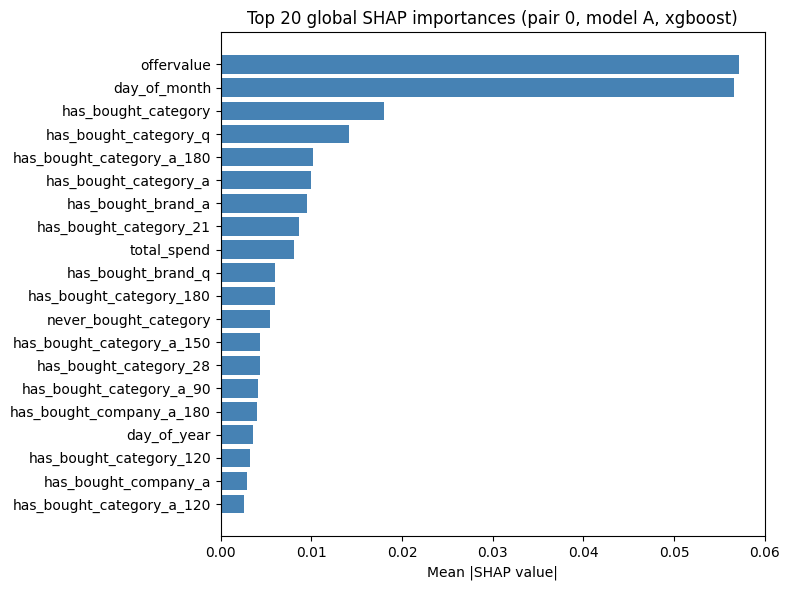

In [7]:
if MODEL_TYPE in ('xgboost', 'mlp_plr'):
    import matplotlib.pyplot as plt

    shap_A_0 = np.load(SHAP_DIR / 'pair_00' / 'shap_A.npy')   # (R, |F|, p)

    # Replica-averaged SHAP for pair 0
    phi_bar_A = shap_A_0.mean(axis=0)   # (|F|, p)

    # Global importance: mean |φ| per feature
    global_imp = np.abs(phi_bar_A).mean(axis=0)
    top_k = 20
    top_idx = np.argsort(global_imp)[::-1][:top_k]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(
        [feature_names[i] for i in top_idx[::-1]],
        global_imp[top_idx[::-1]],
        color='steelblue'
    )
    ax.set_title(f'Top {top_k} global SHAP importances (pair 0, model A, {MODEL_TYPE})')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'global_importance_pair00_A.png', dpi=120)
    plt.show()
